In [1]:
!pip install kagglehub seaborn

In [2]:
import kagglehub
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from PIL import Image

In [3]:
path = kagglehub.dataset_download("rajumavinmar/finger-print-based-blood-group-dataset")
print(path)

100%|██████████| 58.1M/58.1M [00:05<00:00, 10.2MB/s]

Extracting files...


/root/.cache/kagglehub/datasets/rajumavinmar/finger-print-based-blood-group-dataset/versions/1


In [4]:
dataset_path = os.path.join(path, "dataset_blood_group")

data = []

for class_name in os.listdir(dataset_path):
    class_dir = os.path.join(dataset_path, class_name)

    for file in os.listdir(class_dir):
        if file.lower().endswith(('.png', '.jpg', '.jpeg','bmp')):
            data.append([os.path.join(class_dir, file), class_name])

df = pd.DataFrame(data, columns=["image", "label"])
df.head()

,image,label
0,/root/.cache/kagglehub/datasets/rajumavinmar/f...,O-
1,/root/.cache/kagglehub/datasets/rajumavinmar/f...,O-
2,/root/.cache/kagglehub/datasets/rajumavinmar/f...,O-
3,/root/.cache/kagglehub/datasets/rajumavinmar/f...,O-
4,/root/.cache/kagglehub/datasets/rajumavinmar/f...,O-


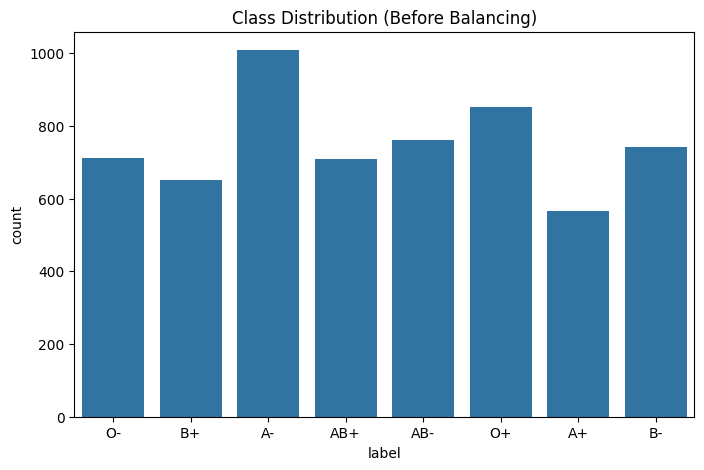

In [5]:
plt.figure(figsize=(8,5))
sns.countplot(x="label", data=df)
plt.title("Class Distribution (Before Balancing)")
plt.show()

In [6]:
print(df["label"].value_counts())

label
A-     1009
O+      852
AB-     761
B-      741
O-      712
AB+     708
B+      652
A+      565
Name: count, dtype: int64


In [7]:
from sklearn.utils import resample

max_count = df["label"].value_counts().max()

df_balanced = []

for label in df["label"].unique():
    df_class = df[df["label"] == label]

    df_class_balanced = resample(
        df_class,
        replace=True,
        n_samples=max_count,
        random_state=42
    )

    df_balanced.append(df_class_balanced)

df_balanced = pd.concat(df_balanced)

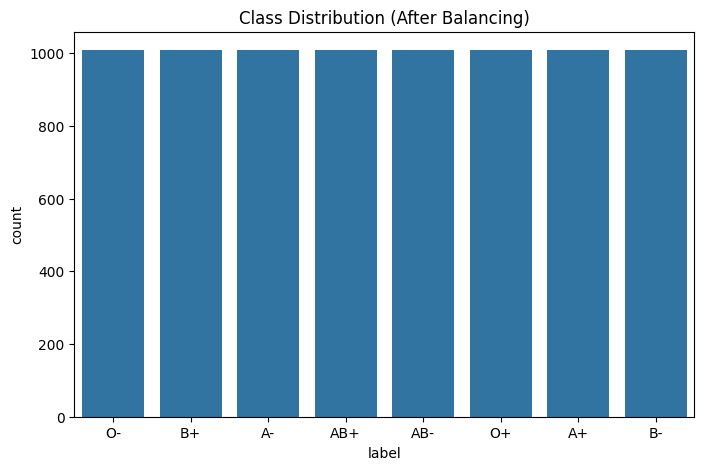

In [8]:
plt.figure(figsize=(8,5))
sns.countplot(x="label", data=df_balanced)
plt.title("Class Distribution (After Balancing)")
plt.show()

In [9]:
print(df_balanced["label"].value_counts())

label
O-     1009
B+     1009
A-     1009
AB+    1009
AB-    1009
O+     1009
A+     1009
B-     1009
Name: count, dtype: int64


In [10]:
TARGET_SIZE = (128,128)

images = []
labels = []

label_names = sorted(df["label"].unique())
label_map = {label: idx for idx, label in enumerate(label_names)}

for i, row in df.iterrows():
    try:
        img = Image.open(row["image"]).convert("RGB")
        img = img.resize(TARGET_SIZE)

        img_array = np.array(img) / 255.0

        images.append(img_array)
        labels.append(label_map[row["label"]])

    except:
        continue

images = np.array(images)
labels = np.array(labels)

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    images, labels, test_size=0.2, random_state=42, stratify=labels
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

In [15]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
model = Sequential()

model.add(Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(128, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.3))   # updated

model.add(Dense(64, activation='relu'))  # keep this

model.add(Dense(len(label_map), activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [16]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [17]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(enumerate(class_weights))

print(class_weights)

{0: np.float64(1.3274336283185841), 1: np.float64(0.7434944237918215), 2: np.float64(1.0600706713780919), 3: np.float64(0.9852216748768473), 4: np.float64(1.1494252873563218), 5: np.float64(1.0118043844856661), 6: np.float64(0.8810572687224669), 7: np.float64(1.0526315789473684)}


In [20]:
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_val, y_val)
)

Epoch 1/20
150/150 ━━━━━━━━━━━━━━━━━━━━ 14s 32ms/step - accuracy: 0.4977 - loss: 1.3325 - val_accuracy: 0.7550 - val_loss: 0.5854
Epoch 2/20
150/150 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.7640 - loss: 0.6250 - val_accuracy: 0.8533 - val_loss: 0.4001
Epoch 3/20
150/150 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.8235 - loss: 0.4595 - val_accuracy: 0.8617 - val_loss: 0.3878
Epoch 4/20
150/150 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.8356 - loss: 0.4187 - val_accuracy: 0.8767 - val_loss: 0.3321
Epoch 5/20
150/150 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.8462 - loss: 0.3924 - val_accuracy: 0.8950 - val_loss: 0.3013
Epoch 6/20
150/150 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.8692 - loss: 0.3414 - val_accuracy: 0.8600 - val_loss: 0.3626
Epoch 7/20
150/150 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.8783 - loss: 0.3149 - val_accuracy: 0.9083 - val_loss: 0.2602
Epoch 8/20
150/150 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.8906 - loss: 0.2869 - val_acc

In [21]:
loss, acc = model.evaluate(X_test, y_test)
print("Test Accuracy:", acc)

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9183 - loss: 0.2469
Test Accuracy: 0.9183333516120911


In [22]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [23]:
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step


In [24]:
print("Classification Report:\n")
print(classification_report(y_test, y_pred))

Classification Report:

              precision    recall  f1-score   support

           0       0.96      0.88      0.92        57
           1       0.90      0.95      0.92       102
           2       0.87      0.92      0.89        72
           3       0.90      0.89      0.90        74
           4       0.91      0.95      0.93        64
           5       0.92      0.94      0.93        71
           6       0.99      0.89      0.93        87
           7       0.92      0.92      0.92        73

    accuracy                           0.92       600
   macro avg       0.92      0.92      0.92       600
weighted avg       0.92      0.92      0.92       600



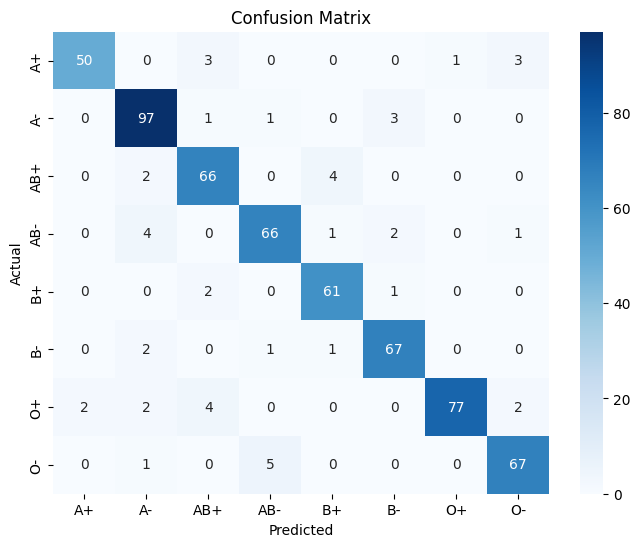

In [25]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_map.keys(),
            yticklabels=label_map.keys())
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

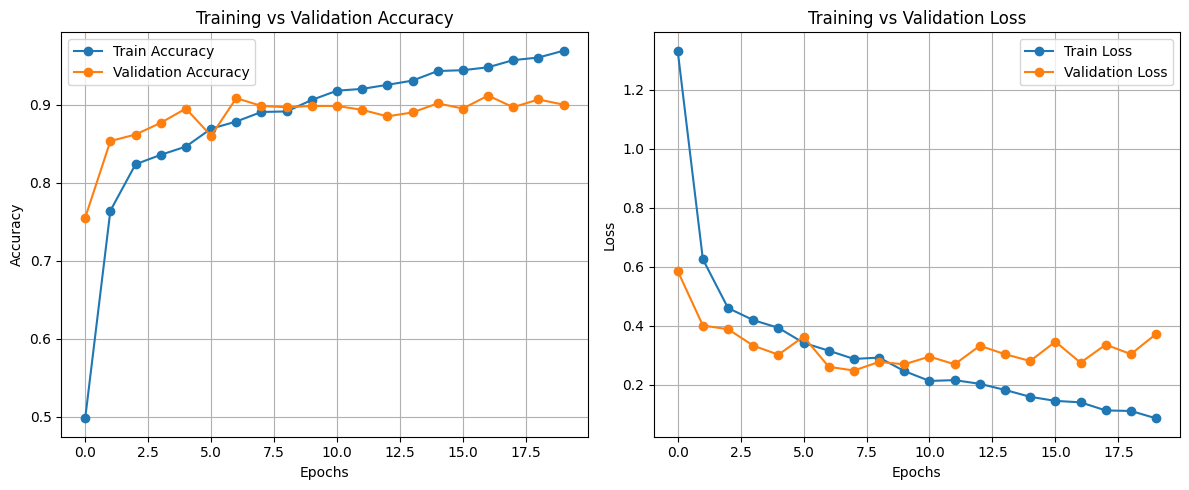

In [27]:
plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], marker='o', label='Train Accuracy')
plt.plot(history.history['val_accuracy'], marker='o', label='Validation Accuracy')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(True)

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], marker='o', label='Train Loss')
plt.plot(history.history['val_loss'], marker='o', label='Validation Loss')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

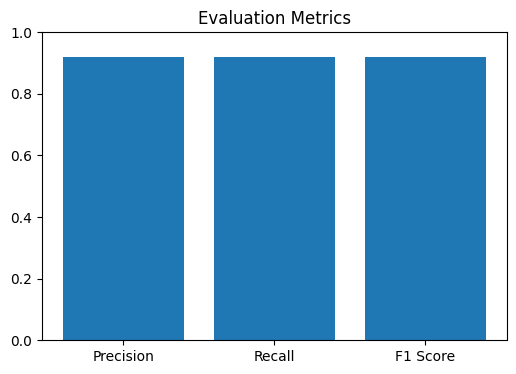

Precision: 0.9202781407666589
Recall: 0.9183333333333333
F1 Score: 0.9184330718297244


In [28]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

metrics = ['Precision', 'Recall', 'F1 Score']
values = [precision, recall, f1]

plt.figure(figsize=(6,4))
plt.bar(metrics, values)
plt.title("Evaluation Metrics")
plt.ylim(0,1)
plt.show()

print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

In [29]:
model.save("blood_group_model_2.h5")

In [30]:

from google.colab import files
files.download("blood_group_model_2.h5")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>